# Validation croisée et ajustement des hyperparamètres

CSI 4506 - automne 2026

Marcel Turcotte  
Version: sept. 24, 2026 17h51

# Préambule

## Message du jour

![](https://static.wixstatic.com/media/a4c5cd_17f35b4279124d5a813dd3e3f61b4d5f~mv2.png/v1/fill/w_1960,h_1102,al_c,q_95,usm_0.66_1.00_0.01,enc_avif,quality_auto/ETH_Apertus_Keyvisual_Final-LY2-3.png)

<a
href="https://ethz.ch/de/news-und-veranstaltungen/eth-news/news/2025/09/medienmitteilung-apertus-ein-vollstaendig-offenes-transparentes-und-mehrsprachiges-sprachmodell.fr.html"
class="external" data-icon="true">Apertus : un modèle linguistique
entièrement ouvert, transparent et multilingue</a>, ETH Zürich,
communiqué de presse, 2025-09-02.

> L’EPFL, l’ETH Zurich et le Centre suisse de supercalcul (CSCS) ont
> publié le 2 septembre Apertus : le premier modèle de langage complet,
> ouvert et multilingue de Suisse. Ils posent ainsi un jalon pour une IA
> générative transparente et diversifiée.

- <a href="https://www.swiss-ai.org/apertus" class="external"
  data-icon="true">www.swiss-ai.org/apertus</a>
- Téléchargements disponibles sur <a
  href="https://huggingface.co/collections/swiss-ai/apertus-llm-68b699e65415c231ace3b059"
  class="external" data-icon="true">Hugging Face</a>
- <a href="https://publicai.co" class="external" data-icon="true">Accès
  public</a>

Le Canada devrait-il entreprendre un tel projet ambitieux ?

Le Canada est reconnu pour sa recherche exceptionnelle en intelligence
artificielle, soutenue par plusieurs institutions et chercheurs de
renom. Parmi les exemples notables :

- L’<a href="https://vectorinstitute.ai/" class="external"
  data-icon="true">Institut Vector</a> à Toronto, qui abrite des
  chercheurs éminents comme
  <a href="https://vectorinstitute.ai/team/geoffrey-hinton/"
  class="external" data-icon="true">Geoffrey Hinton</a>, récipiendaire
  du prix Turing 2018 pour ses travaux pionniers en apprentissage
  profond et du prix Nobel de physique 2024.

- <a href="https://mila.quebec/fr" class="external"
  data-icon="true">Mila</a> à Montréal, dirigé par
  <a href="https://mila.quebec/fr/annuaire/yoshua-bengio" class="external"
  data-icon="true">Yoshua Bengio</a>, un autre lauréat du prix Turing
  2018 reconnu pour ses contributions à l’apprentissage profond.

- L’<a href="https://www.amii.ca" class="external" data-icon="true">Alberta
  Machine Intelligence Institute (Amii)</a>, où
  <a href="https://www.amii.ca/people/richard-s-sutton" class="external"
  data-icon="true">Richard S. Sutton</a> est une figure clé et a reçu le
  prix Turing 2024 pour ses travaux influents en apprentissage par
  renforcement.

Ces institutions et individus soulignent le leadership et l’engagement
continu du Canada dans l’avancement de la recherche en intelligence
artificielle.

L’<a href="https://www.alliancecan.ca/fr" class="external"
data-icon="true">Alliance de recherche numérique du Canada</a>, soutenue
par un <a
href="https://ised-isde.canada.ca/site/isde/fr/strategie-canada-puissance-calcul-souveraine-pour-lia"
class="external" data-icon="true">engagement de 2 milliards de dollars
du gouvernement du Canada en 2024</a>, fournit une infrastructure de
pointe pour la recherche avancée. Notamment, la ressource de calcul
haute performance
<a href="https://docs.alliancecan.ca/wiki/Nibi" class="external"
data-icon="true">Nibi</a> a été lancée le 31 juillet 2025. Elle comprend
134 400 cœurs de CPU et 288 GPU NVIDIA H100, augmentant considérablement
la capacité de calcul. Pour plus de spécifications techniques, consultez
la <a href="https://docs.alliancecan.ca/wiki/Technical_documentation"
class="external" data-icon="true">documentation technique</a>.

## Objectifs d’apprentissage

- **Distinguer** les rôles des données d’entraînement, de validation et
  de test dans le développement du modèle et son évaluation finale.
- **Expliquer** comment la validation croisée à $k$ plis entraîne un
  nouveau modèle à chaque itération, puis interpréter la moyenne et
  l’écart-type de scores de plis qui ne sont pas indépendants.
- **Prévenir** les fuites de données en ajustant le prétraitement dans
  chaque pli et en appliquant les transformations mémorisées aux
  exemples de validation et de test.
- **Distinguer** les paramètres appris par le modèle des hyperparamètres
  et expliquer pourquoi les hyperparamètres qui interagissent doivent
  être évalués conjointement.
- **Appliquer** `GridSearchCV` pour ajuster plusieurs pipelines avec une
  métrique commune et expliquer quand une recherche aléatoire est utile.
- **Comparer** les familles de modèles ajustées, réajuster le pipeline
  sélectionné sur toutes les données d’entraînement et l’évaluer une
  seule fois sur l’ensemble de test intact.

# Introduction

## Jeu de données : OpenML

>  **<a href="https://www.openml.org" class="external"
> data-icon="true">www.openml.org</a>**
>
> OpenML est une plateforme ouverte pour partager des jeux de données,
> des algorithmes et des expériences afin d’améliorer collectivement les
> méthodes d’apprentissage.

. . .

In [1]:
import numpy as np
seed = 42

from sklearn.datasets import fetch_openml

diabetes = fetch_openml(name="diabetes", version=1)
print(diabetes.DESCR)

Le jeu de données sur le diabète des Indiennes Pima contient 768
exemples et huit attributs numériques. Sa taille permet d’effectuer
plusieurs validations croisées pendant le cours. Toutefois, sa
population restreinte, son ancienneté et ses limites de qualité ne
permettent pas d’en tirer des conclusions médicales générales.

## Jeu de données : `return_X_y`

`fetch_openml` retourne un objet `Bunch` par défaut, ou `X` et `y`
lorsque `return_X_y=True`.

In [2]:
X, y = fetch_openml(
    name="diabetes",
    version=1,
    return_X_y=True,
)

. . .

La classe positive est moins fréquente, mais les deux classes
contiennent assez d’exemples pour une validation croisée stratifiée.

In [3]:
print(y.value_counts())

class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

. . .

Conversion des étiquettes cibles en 0 et 1 :

In [4]:
y = y.map({"tested_negative": 0, "tested_positive": 1})

Le jeu de données contient 500 exemples négatifs et 268 exemples
positifs, soit une répartition d’environ 65:35. Ce déséquilibre modéré
ne justifie pas automatiquement le rééchantillonnage ou la pondération
des classes. La stratification préserve approximativement ces
proportions dans les partitions d’entraînement, de validation et de
test, mais elle ne corrige pas le déséquilibre.

Une intervention supplémentaire devrait dépendre de l’objectif
d’évaluation et des conséquences relatives des faux positifs et des faux
négatifs. Les méthodes de traitement du déséquilibre des classes seront
étudiées plus tard. L’AUROC demeure utile ici pour comparer le
classement produit par les scores, tandis que le rapport de
classification final révèle les différences de performance propres à
chaque classe.

## Mesures manquantes

Dans cet exemple, les valeurs nulles de cinq mesures cliniques sont
considérées comme manquantes. La valeur zéro demeure valide pour le
nombre de grossesses.

In [5]:
missing_value_columns = ["plas", "pres", "skin", "insu", "mass"]

X = X.copy()
X[missing_value_columns] = X[missing_value_columns].replace(0, np.nan)

X[missing_value_columns].isna().sum()

plas      5
pres     35
skin    227
insu    374
mass     11
dtype: int64

Cette règle de remplacement découle de la signification des attributs et
n’estime aucune valeur à partir du jeu de données. L’imputation par la
médiane sera apprise plus tard à partir de chaque pli d’ajustement, ce
qui empêche un pli de validation ou l’ensemble de test d’influencer la
transformation.

# Validation croisée

## Ensembles d’entraînement et de test

Cette division est souvent appelée **méthode de retenue** (*holdout
method*).

- **Point de départ courant :** allouer **80 %** des données à
  l’**entraînement** et réserver **20 %** pour le test.

- **Ensemble d’entraînement :** utilisé pour ajuster les modèles et
  prendre les décisions de modélisation.

- **Ensemble de test :** sous-ensemble **indépendant** utilisé une seule
  fois pour l’évaluation finale.

### Ratios courants d’entraînement et de test

1.  **Division 80:20**
    - **Entraînement :** 80 % des données.
    - **Test :** 20 % des données.
    - Ce choix fréquent équilibre la quantité de données disponible pour
      l’entraînement et celle qui sert à évaluer la performance.
2.  **Division 90:10**
    - **Entraînement :** 90 % des données.
    - **Test :** 10 % des données.
    - Cette division peut convenir à un grand jeu de données lorsque 10
      % fournit encore assez d’exemples pour une évaluation utile.

### Facteurs qui influencent le ratio

1.  **Taille du jeu de données**
    - Pour un grand jeu de données, une plus petite proportion peut être
      réservée au test si elle contient toujours assez d’exemples.
2.  **Complexité du modèle**
    - Les modèles complexes comportant de nombreux paramètres peuvent
      nécessiter davantage de données d’entraînement pour éviter le
      surajustement.
3.  **Données de validation**
    - La validation croisée réutilise les données d’entraînement pour la
      validation. Un ensemble de validation séparé peut être préférable
      lorsque le coût de calcul ou la structure des données rend la
      validation croisée peu pratique.
4.  **Classes déséquilibrées**
    - Les deux partitions doivent contenir assez d’exemples de chaque
      classe. **L’échantillonnage stratifié préserve approximativement
      les proportions des classes dans les ensembles d’entraînement et
      de test.**

## Ensembles d’entraînement et de test

**Erreur d’entraînement :** erreur de prédiction mesurée sur les
exemples qui ont servi à ajuster le modèle.

- L’ajustement cherche généralement à réduire la perte ou l’erreur
  d’entraînement.
- Une faible erreur d’entraînement ne garantit pas une faible erreur de
  généralisation.

## Ensembles d’entraînement et de test

**Erreur de généralisation :** erreur de prédiction attendue sur de
nouveaux exemples provenant de conditions semblables.

Elle ne peut pas être observée directement. Les scores de validation et
de test l’estiment à partir d’échantillons finis.

## Ensembles d’entraînement et de test

**Sous-ajustement :**

- **Erreur d’entraînement élevée**.
- Le modèle est trop simple pour représenter les régularités
  sous-jacentes.
- La performance est faible sur les données d’entraînement et les
  nouvelles données.

**Surajustement :**

- Erreur d’entraînement faible, mais **erreur de généralisation
  élevée**.
- Le modèle représente du bruit ou des régularités non pertinentes.
- La performance est faible sur de nouvelles données.

## Définition

La **validation croisée** estime la performance d’une procédure de
construction de modèle sur des exemples inédits.

Elle partitionne plusieurs fois les données d’entraînement, **entraîne
un nouveau classificateur sur certains plis** et **évalue ce
classificateur sur le pli restant**. L’ensemble de test demeure intact.

## Validation croisée à $k$ plis

1.  **Diviser** les données d’entraînement en **$k$ parties
    approximativement égales**, appelées plis.
2.  **Répéter $k$ fois :**
    - Partir d’un **nouveau classificateur non ajusté**.
    - L’entraîner sur **$k-1$ plis**.
    - L’évaluer sur le **pli de validation restant**.
3.  **Agrégation :** résumer les $k$ scores produits par les $k$
    classificateurs entraînés séparément.

Les valeurs 5 et 10 sont des choix courants pour $k$.

Chaque itération produit un classificateur ajusté distinct. Les
paramètres appris ne sont pas transmis d’une itération à la suivante. La
validation croisée évalue donc une procédure de construction de modèle
plutôt qu’un classificateur persistant.

Les $k$ scores décrivent la performance sur différents plis de
validation. Leur moyenne dépend moins d’une division de validation
arbitraire qu’un seul score de validation.

Les classificateurs ajustés partagent néanmoins la majorité de leurs
exemples d’entraînement. Avec cinq plis, deux classificateurs
quelconques partagent trois plis complets, soit 60 % de l’ensemble
d’entraînement complet ou 75 % des exemples utilisés pour ajuster l’un
ou l’autre. Leurs plis de validation diffèrent, mais les classificateurs
ajustés et leurs scores sont donc liés plutôt qu’indépendants.

L’écart-type décrit la variation observée entre ces plis particuliers.
Il ne constitue pas une erreur-type, et le diviser par $\sqrt{k}$ ne
produit pas un intervalle de confiance valide. Une petite valeur ne
suffit pas à établir la stabilité de la procédure d’apprentissage. Une
grande valeur peut refléter des plis de validation particulièrement
difficiles ou de composition différente.

Après la sélection du modèle et des hyperparamètres, un classificateur
final est ajusté sur l’ensemble d’entraînement complet.

In [6]:
import matplotlib.pyplot as plt

def plot_k_fold_cross_validation(k):
    fig, ax = plt.subplots()

    matrix = np.ones((k, k))
    np.fill_diagonal(matrix, 0)

    ax.imshow(matrix, cmap="binary", interpolation="none")

    for i in range(k):
        for j in range(k):
            label = "Validation" if i == j else "Entraînement"
            color = "black" if i == j else "white"
            ax.text(j, i, label, ha="center", va="center", color=color)

    ax.set_xticks(np.arange(k))
    ax.set_yticks(np.arange(k))
    ax.set_xticklabels([f"Pli {i+1}" for i in range(k)])
    ax.set_yticklabels([f"Itération {i+1}" for i in range(k)])
    plt.title(f"Validation croisée à {k} plis")

    ax.grid(False)
    plt.show()

## Validation croisée à 5 plis

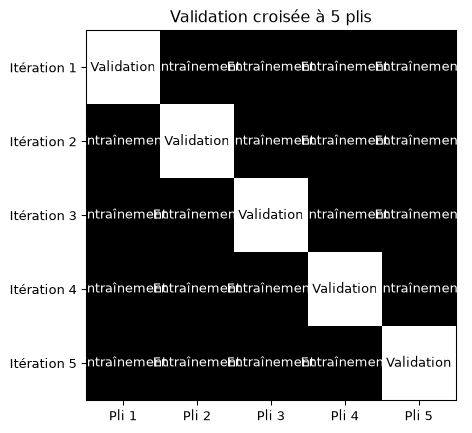

In [7]:
plot_k_fold_cross_validation(5)

À chaque itération, $4/5$ des données d’entraînement servent à
l’ajustement et $1/5$ à la validation.

Chaque ligne représente une itération. Chaque pli sert une fois de pli
de validation et quatre fois de partie des données d’ajustement. Ces
plis proviennent uniquement de la portion d’entraînement du jeu de
données initial. Les exemples de test mis de côté ne participent pas à
ce processus.

## Évaluation sur les plis de validation

- Pendant la sélection du modèle, la validation croisée moyenne les
  scores de **plusieurs plis de validation** plutôt que de dépendre
  d’une seule partition.
- Un score par pli révèle la **sensibilité** aux exemples de validation
  particuliers.
- La **moyenne** et l’**écart-type** résument les scores des plis, mais
  ceux-ci ne sont pas indépendants.

L’ensemble de test final est lui aussi un échantillon fini, et son score
dépend des exemples qu’il contient. Son rôle n’est pas d’éliminer la
variabilité d’échantillonnage. Il fournit une évaluation finale avec des
exemples qui n’ont influencé ni le modèle ni la sélection des
hyperparamètres.

La consultation répétée d’autres divisions de test permettrait à leurs
résultats d’influencer le développement et les transformerait
progressivement en données de validation. Lorsque l’incertitude du score
final importe, elle devrait être quantifiée à l’aide d’un intervalle de
confiance approprié ou d’une procédure *bootstrap* appliquée aux
prédictions de test intactes. Une validation croisée imbriquée ou un jeu
de données externe réellement indépendant constitue une autre option
lorsqu’un seul ensemble de test ne suffit pas.

## Estimation de la généralisation

- La validation croisée **estime** la performance sur des **exemples
  inédits** provenant de conditions semblables.
- Elle n’améliore pas directement la généralisation. Elle permet de
  **comparer les choix de modélisation** en utilisant uniquement les
  données d’entraînement.
- L’**ensemble de test intact** fournit l’évaluation finale après ces
  choix.

## Utilisation efficace des données

- La validation croisée est particulièrement **utile lorsque les données
  sont limitées**.
- Au fil des $k$ itérations, **chaque exemple d’entraînement** apparaît
  **une fois dans un pli de validation** et **$k-1$ fois dans un pli
  d’ajustement**.
- Après la sélection, la procédure choisie peut être réajustée sur
  l’**ensemble d’entraînement complet**.

Les exemples ne sont pas nécessairement aussi informatifs les uns que
les autres pour l’algorithme d’apprentissage. La composition de chaque
pli d’ajustement et de validation peut donc influencer son score.

## Ajustement des hyperparamètres

- La validation croisée compare des **configurations d’hyperparamètres**
  avec les mêmes plis et la même métrique d’évaluation.
- La configuration sélectionnée possède la **meilleure performance
  estimée** parmi les candidates évaluées.

Le score de validation croisée le plus élevé sert à sélectionner la
configuration d’hyperparamètres. Il peut donc être légèrement optimiste.
L’évaluation finale sur l’ensemble de test estime la performance de la
procédure de sélection complète avec des données qui n’ont pas influencé
ce choix.

## Défis

- **Coût de calcul :** la validation exige des ajustements répétés.
  - La méthode **leave-one-out** (LOO) représente le cas extrême où
    (k=N).
- **Déséquilibre des classes :** des plis aléatoires peuvent mal
  représenter les classes minoritaires.
  - La **validation croisée stratifiée** maintient approximativement les
    proportions des classes.
- **Complexité de mise en œuvre :** les implémentations manuelles
  favorisent les erreurs, surtout avec la **validation croisée
  imbriquée**, le **rééchantillonnage bootstrap** ou l’intégration à des
  pipelines plus complexes.

La validation croisée *leave-one-out* ajuste le modèle une fois pour
chaque exemple. Ses ensembles d’entraînement ne diffèrent que d’un seul
exemple, ce qui peut produire une estimation très variable pour
certaines procédures d’apprentissage, en plus d’être coûteux en calcul.
La validation croisée à cinq ou dix plis constitue généralement un choix
plus pratique.

La **validation croisée stratifiée** préserve approximativement la
distribution des classes dans chaque pli afin que chaque classe soit
représentée dans les partitions d’ajustement et de validation.

Les plis aléatoires ordinaires supposent également que les exemples
peuvent être échangés sans modifier le problème. Les mesures répétées
d’une même personne exigent des plis qui tiennent compte des groupes,
tandis que les prédictions portant sur l’avenir exigent une division
temporelle.

# Ajustement des hyperparamètres

## Flux de travail

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)

**Attribution :** <a
href="https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation"
class="external" data-icon="true">Cross-validation: evaluating estimator
performance</a>

Ce flux de travail distingue trois usages des données :
**entraînement**, **validation** et **test**. Les plis de validation
soutiennent la sélection du modèle, tandis que l’ensemble de test
demeure à l’extérieur de ce processus.

## Flux de travail : mise en œuvre

In [8]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed,
)
selection_metric = "roc_auc"

L’ensemble de test est séparé avant la validation croisée et
l’ajustement des hyperparamètres. La stratification préserve
approximativement les mêmes proportions de classes dans les deux
partitions. L’objet de validation croisée explicite rend les plis
reproductibles et garantit que chaque modèle utilise les mêmes
partitions de validation.

L’AUROC constitue la métrique de sélection dans tout cet exemple. Le
choix d’une autre métrique pourrait modifier les hyperparamètres et le
modèle sélectionnés.

## Fuite de données pendant la validation croisée

Une **fuite de données** survient lorsque l’information d’un pli de
validation influence la procédure ajustée sur les autres plis.

``` python
# Incorrect : le scaler voit tous les futurs plis de validation

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

scores = cross_val_score(
    KNeighborsClassifier(),
    X_train_scaled,
    y_train,
    cv=cv,
)
```

Les exemples de validation influencent les moyennes et les échelles qui
servent à les évaluer.

Garder l’ensemble de test final intact ne rend pas cette procédure de
validation croisée valide. L’appel à `fit_transform` précède la création
des plis. Le scaler calcule donc la moyenne et l’échelle de chaque
attribut à partir de tout `X_train`. Chaque pli de validation contribue
ainsi à son propre prétraitement.

L’application de `fit_transform` au jeu de données complet `X` avant la
division en ensembles d’entraînement et de test serait encore plus
grave. La transformation ajustée contiendrait alors de l’information
provenant des exemples de test. L’ensemble de test ne fournirait plus
une évaluation indépendante de la procédure de modélisation complète.

Il s’agit d’une fuite même si la mise à l’échelle n’utilise pas les
étiquettes cibles. Le même problème s’applique à l’imputation, à la
sélection des attributs, à l’analyse en composantes principales, au
rééchantillonnage et à toute opération dépendante des données réalisée
avant la validation croisée.

Un pipeline empêche cette forme de fuite uniquement pour les opérations
qui se trouvent à l’intérieur du pipeline. Il ne peut pas corriger une
fuite de cible, une division temporelle inadéquate ou la présence
d’observations répétées d’une même personne dans les plis d’ajustement
et de validation.

## `fit_transform` et `transform`

- `fit(X)` **apprend** de l’information à partir de `X`.
- `fit_transform(X)` apprend cette information et **applique** la
  transformation aux mêmes exemples.
- `transform(X)` applique l’**information mémorisée** sans la
  recalculer.

``` python
scaler = StandardScaler()

X_fitting_folds_scaled = scaler.fit_transform(X_fitting_folds)
X_validation_fold_scaled = scaler.transform(X_validation_fold)
```

Les exemples de validation, de test et les exemples futurs reçoivent
`transform`, jamais `fit` ou `fit_transform`.

Pour `StandardScaler`, `fit` apprend et mémorise des attributs comme
`mean_` et `scale_`. Pour `SimpleImputer`, la méthode mémorise dans
`statistics_` la valeur de remplacement de chaque attribut.
Conceptuellement, `fit_transform(X)` exécute `fit(X)`, puis
`transform(X)` sur les mêmes exemples d’ajustement.

La fuite de données constitue un problème méthodologique grave. Elle a
fait l’objet de nombreuses séances dans des conférences et ateliers sur
l’apprentissage automatique, car un prétraitement apparemment
inoffensif, mais effectué au mauvais moment, peut invalider une
évaluation.

Le transformateur ajusté conserve cet état en mémoire. Un pipeline
ajusté conserve l’état de chaque étape de prétraitement avec les
paramètres appris par le classificateur. Un appel à `predict` ou à
`predict_proba` sur de nouveaux exemples applique automatiquement chaque
transformation mémorisée avant d’invoquer le classificateur.

La conservation de cet état en mémoire ne signifie pas qu’il est
enregistré de façon permanente. Le déploiement exige la sérialisation
explicite du pipeline ajusté complet afin que les exemples futurs
reçoivent les mêmes transformations. Le cours 10 abordera ces aspects
d’ingénierie.

## Prétraitement dans chaque pli

Pour chaque pli, la validation croisée crée et ajuste un **nouveau
pipeline**.

| Étape du pipeline | Plis d’ajustement | Pli de validation                     |
|-------------------|-------------------|---------------------------------------|
| Imputation        | `fit_transform`   | `transform`                           |
| Mise à l’échelle  | `fit_transform`   | `transform`                           |
| Classificateur    | `fit`             | `predict_proba` / `decision_function` |

Les médianes, les moyennes et les échelles apprises ne sont pas
transmises au pli suivant.

À chaque itération, scikit-learn clone le pipeline non ajusté. L’appel à
`fit` ajuste chaque transformateur sur les plis d’ajustement et transmet
sa sortie transformée à l’étape suivante. Le classificateur est ensuite
ajusté sur les exemples entièrement transformés.

Lors de l’évaluation du pli de validation, le pipeline appelle
uniquement `transform` sur l’imputation et la mise à l’échelle. Leurs
statistiques mémorisées proviennent exclusivement des plis d’ajustement.
Le pipeline temporaire ajusté est abandonné après l’évaluation du pli,
puis l’itération suivante commence avec un nouveau clone non ajusté.

`GridSearchCV` répète ce processus complet pour chaque combinaison
d’hyperparamètres. Après avoir sélectionné une configuration, il
réajuste le pipeline complet sur toutes les données d’entraînement et le
conserve dans `best_estimator_`. Les exemples de test intacts reçoivent
alors uniquement les transformations mémorisées dans ce pipeline final.

## Pipelines de prétraitement

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=seed)),
])

knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier()),
])

logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="saga",
        max_iter=3000,
        random_state=seed,
    )),
])

L’imputation appartient à chaque pipeline afin d’apprendre ses médianes
à partir d’un pli d’ajustement, puis de les appliquer au pli de
validation correspondant. KNN et la régression logistique utilisent
également des attributs standardisés, car leurs calculs dépendent des
distances ou de l’optimisation des coefficients. Les arbres de décision
divisent les données selon un attribut à la fois et n’exigent pas de
mise à l’échelle.

La valeur fixe de `max_iter` donne à l’optimiseur de la régression
logistique assez d’itérations pour converger. Il s’agit d’un contrôle
d’implémentation, et non d’un réglage de la complexité du modèle à
optimiser pour la performance prédictive.

## `cross_val_score`

In [10]:
knn_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=selection_metric,
)

print("Scores :", knn_scores)
print(f"AUROC moyenne : {knn_scores.mean():.3f}")
print(f"Écart-type : {knn_scores.std():.3f}")

Scores : [0.81133721 0.76061047 0.84447674 0.74883721 0.75639881]
AUROC moyenne : 0.784
Écart-type : 0.037

<a
href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html"
class="external"
data-icon="true">sklearn.model_selection.cross_val_score</a>. Voir aussi
<a
href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate"
class="external" data-icon="true">cross_validate</a>.

Chaque score provient d’un pli de validation différent. La moyenne
résume les cinq résultats de validation. L’écart-type décrit leur
variation, mais il ne constitue pas un intervalle de confiance puisque
les modèles ajustés partagent plusieurs exemples d’entraînement.

Ici, `cross_val_score` reçoit le pipeline KNN complet. L’imputation et
la mise à l’échelle sont donc réajustées dans chaque pli avant
l’ajustement du classificateur. Le passage d’un tableau déjà imputé ou
standardisé à l’aide de tout `X_train` contournerait cette protection.

## Paramètres du modèle et hyperparamètres

Les **paramètres du modèle** sont appris à partir des données
d’entraînement.

Les **hyperparamètres** sont choisis avant chaque ajustement et
contrôlent la structure du modèle ou le processus d’apprentissage.

Parmi les hyperparamètres figurent `max_depth` pour un arbre,
`n_neighbors` pour KNN et `C` pour la régression logistique.
L’ajustement des hyperparamètres utilise la performance de validation
pour choisir parmi les configurations candidates. L’algorithme
d’apprentissage ajuste de nouveaux paramètres de modèle pour chaque
candidate et chaque pli de validation croisée.

## Hyperparamètres : arbre de décision

- `criterion` choisit la mesure de qualité d’une division : `gini`,
  `entropy` ou `log_loss`.
- `max_depth` limite la **profondeur maximale** de l’arbre.

**Voir :** <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html"
class="external" data-icon="true">DecisionTreeClassifier</a>

## Hyperparamètres : régression logistique

- `C` représente l’inverse de la force de régularisation. Les petites
  valeurs appliquent une régularisation plus forte.
- `l1_ratio` choisit l’équilibre entre les régularisations L2 et L1
  lorsque le solveur `saga` est utilisé.

**Voir :** <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"
class="external" data-icon="true">LogisticRegression</a>.

## Hyperparamètres : KNN

- `n_neighbors` indique le nombre de voisins utilisés pour effectuer une
  prédiction.
- `weights` donne la même influence aux voisins (`uniform`) ou une
  influence plus grande aux voisins proches (`distance`).

**Voir :** <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html"
class="external" data-icon="true">KNeighborsClassifier</a>

## Expérience : `n_neighbors`

In [11]:
neighbor_scores = {}
neighbor_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]

for value in neighbor_values:
    candidate = knn_pipeline.set_params(
        model__n_neighbors=value,
        model__weights="uniform",
    )
    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=selection_metric,
    )
    neighbor_scores[value] = scores.mean()
    print(f"n_neighbors={value:2d} : {scores.mean():.3f}")

best_n_neighbors = max(neighbor_scores, key=neighbor_scores.get)
print("Meilleur n_neighbors :", best_n_neighbors)

n_neighbors= 1 : 0.664
n_neighbors= 3 : 0.764
n_neighbors= 5 : 0.784
n_neighbors= 7 : 0.798
n_neighbors= 9 : 0.815
n_neighbors=11 : 0.822
n_neighbors=15 : 0.832
n_neighbors=21 : 0.831
n_neighbors=31 : 0.831
Meilleur n_neighbors : 15

## Expérience : `weights`

In [12]:
weight_scores = {}

for value in ["uniform", "distance"]:
    candidate = knn_pipeline.set_params(
        model__n_neighbors=best_n_neighbors,
        model__weights=value,
    )
    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=selection_metric,
    )
    weight_scores[value] = scores.mean()
    print(f"weights={value:8s} : {scores.mean():.3f}")

weights=uniform  : 0.832
weights=distance : 0.833

La première boucle choisit `n_neighbors` en fixant `weights="uniform"`.
La seconde fixe ensuite ce nombre de voisins et fait varier `weights`.
Cette procédure séquentielle ne réexamine jamais `n_neighbors` après le
changement de la règle de pondération. Elle peut donc manquer la
meilleure paire de valeurs.

L’évaluation du produit cartésien des deux ensembles de candidates
corrige cette limite. Le code se réalise facilement avec des boucles
imbriquées, ce qui montre que le principe de la recherche en grille est
simple et peut être mis en œuvre indépendamment.

## Ajustement des hyperparamètres : recherche en grille

- Plusieurs hyperparamètres doivent parfois être considérés
  **conjointement**.

- L’exploration manuelle de leurs combinaisons devient **fastidieuse et
  propice aux erreurs**.

- La **recherche en grille** évalue systématiquement un ensemble
  prédéfini de combinaisons :

  1.  Énumérer le produit cartésien des valeurs candidates.

  2.  Évaluer chaque combinaison avec les mêmes plis de validation
      croisée et la même métrique.

Les boucles manuelles montrent que la recherche en grille peut être mise
en œuvre indépendamment. Une implémentation standardisée apporte
plusieurs avantages pratiques :

- Elle énumère les combinaisons de paramètres de façon cohérente.
- Elle applique séparément chaque étape du pipeline dans chaque pli
  d’ajustement.
- Elle consigne les résultats par pli et les résultats agrégés dans
  `cv_results_`.
- Elle expose `best_params_`, `best_score_` et un `best_estimator_`
  réajusté.
- Elle prend en charge plusieurs métriques, l’exécution parallèle et le
  signalement explicite des erreurs.
- Elle réduit les erreurs d’indexation et de tenue des résultats, et
  facilite la reproductibilité de l’expérience.

L’utilitaire ne décide pas de la métrique, des plis, des modèles ni des
valeurs de paramètres appropriés. Ces choix font toujours partie de la
conception de l’expérience.

## `GridSearchCV` : arbre de décision

In [13]:
from sklearn.model_selection import GridSearchCV

tree_param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, None],
    "model__criterion": ["gini", "entropy", "log_loss"],
}

tree_search = GridSearchCV(
    tree_pipeline,
    tree_param_grid,
    cv=cv,
    scoring=selection_metric,
)
tree_search.fit(X_train, y_train)

(tree_search.best_params_, tree_search.best_score_)

({'model__criterion': 'gini', 'model__max_depth': 4},
 np.float64(0.7881160022148395))

## `GridSearchCV` : KNN

In [14]:
knn_param_grid = {
    "model__n_neighbors": neighbor_values,
    "model__weights": ["uniform", "distance"],
}

knn_search = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring=selection_metric,
)
knn_search.fit(X_train, y_train)

(knn_search.best_params_, knn_search.best_score_)

({'model__n_neighbors': 21, 'model__weights': 'distance'},
 np.float64(0.8336620985603543))

Le double trait de soulignement sépare le nom de l’étape du pipeline du
paramètre de l’estimateur. La recherche en grille évalue maintenant
toutes les combinaisons de `n_neighbors` et de `weights` au lieu de
s’engager sur une valeur avant d’explorer l’autre.

Avec les plis actuels, l’ajustement séquentiel sélectionne 15 voisins
avant de comparer les règles de pondération. La grille conjointe
sélectionne plutôt 21 voisins avec une pondération selon la distance.
Cette différence fournit un exemple concret d’interaction entre
hyperparamètres.

## `GridSearchCV` : régression logistique

In [15]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 1.0],
}

logistic_search = GridSearchCV(
    logistic_pipeline,
    logistic_param_grid,
    cv=cv,
    scoring=selection_metric,
)
logistic_search.fit(X_train, y_train)

(logistic_search.best_params_, logistic_search.best_score_)

({'model__C': 0.1, 'model__l1_ratio': 0.0}, np.float64(0.8443867663344408))

Avec le solveur `saga`, `l1_ratio=0` produit une régularisation L2 et
`l1_ratio=1` une régularisation L1. Toutes les candidates de cette
grille sont compatibles avec le solveur fixe. La recherche fait varier
des propriétés du modèle ajusté plutôt que des contrôles de convergence
comme `max_iter` ou `tol`.

## Comparaison des modèles ajustés

In [16]:
model_searches = {
    "Arbre de décision": tree_search,
    "KNN": knn_search,
    "Régression logistique": logistic_search,
}

for name, search in model_searches.items():
    print(f"{name:22s} : {search.best_score_:.3f}")

best_model_name = max(
    model_searches,
    key=lambda name: model_searches[name].best_score_,
)
best_search = model_searches[best_model_name]

print("Modèle sélectionné :", best_model_name)

Arbre de décision      : 0.788
KNN                    : 0.834
Régression logistique  : 0.844
Modèle sélectionné : Régression logistique

Les trois recherches utilisent les mêmes exemples d’entraînement, les
mêmes plis de validation et la même métrique AUROC. Leurs meilleurs
scores de validation croisée peuvent donc soutenir un choix entre les
familles de modèles. Cette comparaison fait toujours partie de la
sélection du modèle et ne remplace pas l’évaluation sur l’ensemble de
test intact.

Chaque `best_score_` est le score maximal trouvé dans son espace de
recherche plutôt qu’une estimation sans biais de la performance future.
La comparaison d’un plus grand nombre de candidates multiplie les
occasions de sélectionner une configuration avantagée par ces plis
particuliers. L’ensemble de test final fournit une estimation
indépendante de la performance de la procédure de sélection complète.

## Recherche aléatoire

- Une grille devient coûteuse lorsqu’elle contient **de nombreuses
  combinaisons**.
- `RandomizedSearchCV` échantillonne des candidates à partir des valeurs
  ou des distributions fournies.
- Le nombre d’itérations établit un **budget de calcul prévisible**.

**Voir :** <a
href="https://scikit-learn.org/stable/auto_examples/model_selection/plot_randomized_search.html"
class="external" data-icon="true">Comparing randomized search and grid
search for hyperparameter estimation</a>.

## Flux de travail

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)

**Attribution :** <a
href="https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation"
class="external" data-icon="true">Cross-validation: evaluating estimator
performance</a>

Le flux de travail comporte maintenant deux niveaux de sélection : la
sélection des hyperparamètres dans chaque famille de modèles, suivie de
la comparaison des trois familles ajustées. Les deux niveaux utilisent
uniquement les données d’entraînement. L’ensemble de test demeure isolé
jusqu’à l’étape suivante.

## Évaluation finale

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

best_model = best_search.best_estimator_

y_test_score = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)

print("Modèle sélectionné :", best_model_name)
print(f"AUROC de test : {roc_auc_score(y_test, y_test_score):.3f}")
print(classification_report(y_test, y_test_pred))

Modèle sélectionné : Régression logistique
AUROC de test : 0.810
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       100
           1       0.57      0.48      0.52        54

    accuracy                           0.69       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.68      0.69      0.68       154


Après cette évaluation, la procédure de modélisation demeure **figée**.
La réviser puis l’évaluer de nouveau sur le même ensemble de test
utilise le résultat du test pendant le développement du modèle.

Par défaut, `GridSearchCV` réajuste la configuration d’hyperparamètres
sélectionnée sur l’ensemble d’entraînement complet. Le `best_estimator_`
est donc prêt pour l’évaluation unique sur l’ensemble de test.

L’AUROC correspond à la métrique utilisée pendant la sélection. Le
rapport de classification la complète avec la précision, le rappel et
les scores $F_1$, qui dépendent du seuil. Le résultat de test estime la
performance de la procédure de sélection complète et figée sur des
exemples inédits provenant de conditions semblables.

Un résultat décevant incite fortement à modifier le prétraitement, les
attributs, les modèles, la recherche d’hyperparamètres ou la métrique
d’évaluation, puis à recommencer. À ce moment, la performance de test
observée a influencé le développement du modèle, et l’ensemble de test
joue effectivement le rôle de données de validation. Cette réutilisation
adaptative est souvent appelée *entraînement sur l’ensemble de test*,
même si l’algorithme d’apprentissage n’est pas directement ajusté sur
les exemples de test.

L’objectif consiste à obtenir une estimation honnête de la performance
après déploiement, et non le score le plus élevé possible. Si le
développement doit se poursuivre, l’ensemble de test existant ne peut
plus fournir une évaluation finale entièrement indépendante de la
procédure révisée. Cette évaluation exige un nouvel ensemble de test
intact ou un jeu de données externe indépendant.

# Conclusion

## Résumé

- Nous avons réservé un **ensemble de test intact** à une évaluation
  finale unique, après toutes les décisions de modélisation.
- Nous avons utilisé la **validation croisée à $k$ plis** pour entraîner
  un nouveau modèle à chaque itération et résumer les scores de plis
  liés entre eux par leur moyenne et leur écart-type.
- Nous avons prévenu les **fuites de données** en ajustant l’imputation
  et la mise à l’échelle dans chaque pli, puis en appliquant les
  transformations mémorisées aux exemples de validation et de test.
- Nous avons distingué les **paramètres du modèle** appris des
  **hyperparamètres**, puis évalué conjointement les hyperparamètres qui
  interagissent.
- Nous avons utilisé `GridSearchCV` pour ajuster et comparer des
  pipelines d’arbre de décision, de KNN et de régression logistique avec
  les mêmes plis et la même métrique AUROC. La **recherche aléatoire**
  offre une solution de rechange pour les espaces de recherche plus
  vastes.
- Nous avons réajusté le pipeline sélectionné sur toutes les données
  d’entraînement et évalué celui-ci une seule fois sur l’ensemble de
  test. Toute modification ultérieure transformerait cet ensemble de
  test en données de validation.

## Prochain cours

- Après le quiz, nous aborderons l’ingénierie de l’apprentissage
  automatique.

## Références

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa